In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from soccerplots.radar_chart import Radar

In [35]:
df = pd.read_csv('data/radars.csv')
df.head()

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt\Patrick-van-Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham\Tammy-Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams\Che-Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo\Tosin-Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián\Adrian,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches


In [36]:
#Obs: Para dados do FBref, ajeitar o nome do jogador
df['Player'] = df['Player'].str.split('\\', expand=True)[0]
df

,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,Sh,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,Patrick van Aanholt,nl NED,DF,Crystal Palace,30-185,1990,13.7,0,15,...,20.6,3,0,0,0.8,0.8,0.05,-0.8,-0.8,Matches
1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,31,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
2,3,Che Adams,eng ENG,FW,Southampton,24-232,1996,21.2,4,40,...,13.5,0,0,0,5.3,5.3,0.13,-1.3,-1.3,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Fulham,23-159,1997,22.0,0,17,...,9.0,0,0,0,0.9,0.9,0.06,-0.9,-0.9,Matches
4,5,Adrián,es ESP,GK,Liverpool,34-058,1987,3.0,0,0,...,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,501,Andi Zeqiri,ch SUI,FWDF,Brighton,21-253,1999,0.8,0,5,...,12.9,0,0,0,0.3,0.3,0.06,-0.3,-0.3,Matches
501,502,Oleksandr Zinchenko,ua UKR,DF,Manchester City,24-077,1996,10.1,0,8,...,21.1,0,0,0,0.4,0.4,0.06,-0.4,-0.4,Matches
502,503,Hakim Ziyech,ma MAR,FWMF,Chelsea,27-348,1993,8.0,1,22,...,22.2,0,0,0,1.0,1.0,0.05,0.0,0.0,Matches
503,504,Kurt Zouma,fr FRA,DF,Chelsea,26-126,1994,16.0,4,15,...,10.8,0,0,0,1.0,1.0,0.07,3.0,3.0,Matches


In [37]:
#Operações binárias em dataframes usam apenas um & para "E" e um | para "OU", além de precisar de parênteses para cada condição
df = df[(df['Player'] == "Tammy Abraham") | (df['Player'] == "Timo Werner")].reset_index()
df

,index,Rk,Player,Nation,Pos,Squad,Age,Born,90s,Gls,...,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,1,2,Tammy Abraham,eng ENG,FW,Chelsea,23-151,1997,11.3,6,...,9.9,0,0,0,5.6,5.6,0.18,0.4,0.4,Matches
1,481,482,Timo Werner,de GER,FW,Chelsea,24-361,1996,20.5,5,...,13.7,0,0,0,8.4,8.4,0.15,-3.4,-3.4,Matches


In [38]:
df = df.drop(['index', 'Rk', 'Nation', 'Matches', 'Pos', 'Squad', 'Age', 'Born', '90s', 'PK', 'PKatt', 'FK'], axis=1)
df

,Player,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,Dist,xG,npxG,npxG/Sh,G-xG,np:G-xG
0,Tammy Abraham,6,31,13,41.9,2.73,1.15,0.19,0.46,9.9,5.6,5.6,0.18,0.4,0.4
1,Timo Werner,5,55,21,38.2,2.69,1.03,0.09,0.24,13.7,8.4,8.4,0.15,-3.4,-3.4


In [39]:
params = list(df.columns)[1:]
params

['Gls',
 'Sh',
 'SoT',
 'SoT%',
 'Sh/90',
 'SoT/90',
 'G/Sh',
 'G/SoT',
 'Dist',
 'xG',
 'npxG',
 'npxG/Sh',
 'G-xG',
 'np:G-xG']

In [40]:
ranges = []
a_values = []
b_values = []

for x in params:
    a = min(df[params][x])
    a = a - (a * .25)
    b = max(df[params][x])
    b = b + (b*.25)
    ranges.append((a, b))

for x in range(len(df['Player'])):
    if df['Player'][x] == 'Tammy Abraham':
        a_values = df.iloc[x].values.tolist()[1:]
    else:
        b_values = df.iloc[x].values.tolist()[1:]

In [41]:
values = [a_values, b_values]

In [42]:
title = dict(title_name='Tammy Abraham', title_color='red', subtitle_name='Chelsea FC', subtitle_color='red', title_name2 = 'Timo Werner', title_color2 = 'blue', subtitle_name2='Chelsea FC', subtitle_color2='blue', title_fontsize=15, subtitle_fontsize=15)

endnote = '@camilo_31_ \n Data: via FBref.com / Statsbomb.com'

findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Font family 'Liberation Serif' not found.
findfont: Fo

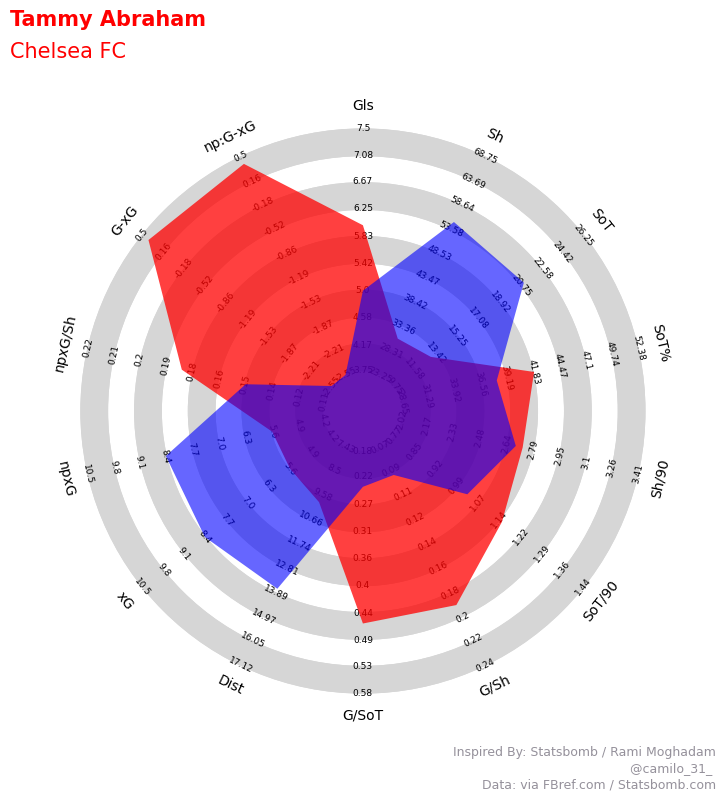

In [43]:
radar = Radar()

fig, ax = radar.plot_radar(ranges=ranges, params=params, values=values, radar_color=['red', 'blue'], title=title, endnote=endnote, 
                           alphas=[.75, .6], compare=True)